# MAIN STEP 2 — Graph Construction (For PageRank & Louvain)

cleaned_biogrid_ppi.csv contaiins : proteinA , proteinB    =>This is an edge list.
But algorithms like PageRank & Louvain DO NOT work directly on strings. We must convert this into a mathematical graph representation.

# Step 2.1 — Convert Protein Names → Integer IDs

In [6]:
import pandas as pd

ppi = pd.read_csv("cleaned_biogrid_ppi.csv")

# Get all unique proteins
unique_proteins = pd.unique(
    ppi[["Official Symbol Interactor A",
         "Official Symbol Interactor B"]].values.ravel()
)

# Map protein → integer
protein_to_id = {protein: idx for idx, protein in enumerate(unique_proteins)}

# Replace names with IDs
ppi["source"] = ppi["Official Symbol Interactor A"].map(protein_to_id)
ppi["target"] = ppi["Official Symbol Interactor B"].map(protein_to_id)

print(ppi.head())


  Official Symbol Interactor A Official Symbol Interactor B  source  target
0                       MAP2K4                         FLNC       0       1
1                         MYPN                        ACTN2       2       3
2                        ACVR1                         FNTA       4       5
3                        GATA2                          PML       6       7
4                         RPA2                        STAT3       8       9


# step 2.2 — Create Undirected Edge List

Because PPI is undirected: If (A,B) exists → we must add (B,A)

In [7]:
edges = ppi[["source", "target"]].values

# Add reverse edges
import numpy as np
reverse_edges = edges[:, ::-1]

# Combine both
all_edges = np.vstack([edges, reverse_edges])


# Step 2.3 — Build Sparse Adjacency Matrix

In [8]:
from scipy.sparse import csr_matrix

num_nodes = len(unique_proteins)

row = all_edges[:, 0]
col = all_edges[:, 1]

data = np.ones(len(row))

adj_matrix = csr_matrix((data, (row, col)),
                        shape=(num_nodes, num_nodes))

print("CSR matrix shape:", adj_matrix.shape)
print("Number of non-zeros:", adj_matrix.nnz)


CSR matrix shape: (27295, 27295)
Number of non-zeros: 1994884


# Step 2.4 — Verify Graph Properties

In [9]:
print("Number of nodes:", num_nodes)
print("Number of edges (undirected):", adj_matrix.nnz // 2)


Number of nodes: 27295
Number of edges (undirected): 997442


# Step 2.5 — Optional: Convert to NetworkX Graph

In [10]:
import networkx as nx

G = nx.from_scipy_sparse_array(adj_matrix)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Graph density:", nx.density(G))



Number of nodes: 27295
Number of edges: 997442
Graph density: 0.00267773355748139


# STEP 3 — CPU PageRank

# STEP 3.1 — CPU PageRank Using NetworkX

In [11]:
import time
import networkx as nx

start_time = time.time()

pagerank_scores = nx.pagerank(G, alpha=0.85)

end_time = time.time()

print("CPU PageRank completed.")
print("Execution time:", end_time - start_time, "seconds")


CPU PageRank completed.
Execution time: 2.611084222793579 seconds


# STEP 3.2 — Extract Top 10 Proteins

In [12]:
id_to_protein = {v: k for k, v in protein_to_id.items()}


In [13]:
# Sort by PageRank score
top_10 = sorted(pagerank_scores.items(),
                key=lambda x: x[1],
                reverse=True)[:10]

print("\nTop 10 Proteins by PageRank:\n")

for node_id, score in top_10:
    print(id_to_protein[node_id], ":", score)



Top 10 Proteins by PageRank:

NR3C1 : 0.004129378860225
CCNF : 0.0032273934191245418
UBC : 0.0031891956633668186
TRIM67 : 0.0023838488581015707
OTUD4 : 0.0021957426299043445
TRIM25 : 0.0019917385702749053
SNCA : 0.0018374966285425421
ZRANB1 : 0.001673015321264632
KIAA1429 : 0.00162422062555868
PARK2 : 0.0015381622912957807


# STEP 3.3 — Basic Statistics


In [14]:
print("\nPageRank Summary:")
print("Max score:", max(pagerank_scores.values()))
print("Min score:", min(pagerank_scores.values()))



PageRank Summary:
Max score: 0.004129378860225
Min score: 5.792920043551091e-06


# STEP 3.4 — Optional: Plot Top 10

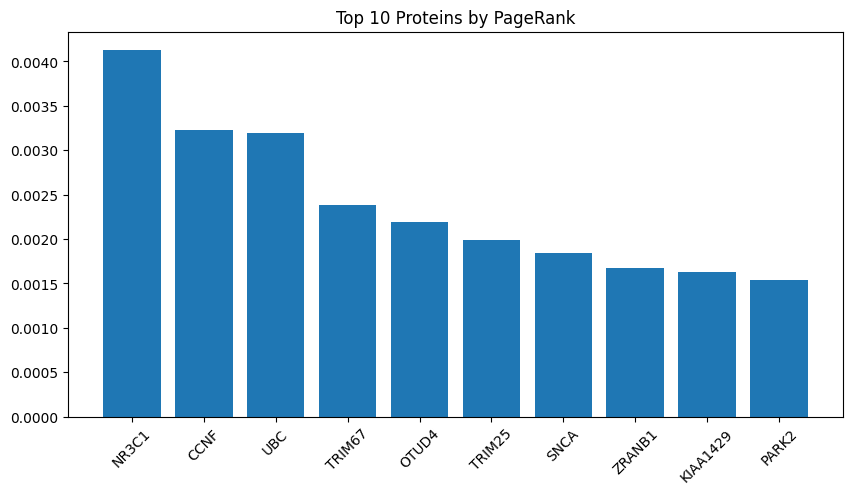

In [15]:
import matplotlib.pyplot as plt

proteins = [id_to_protein[node] for node, _ in top_10]
scores = [score for _, score in top_10]

plt.figure(figsize=(10,5))
plt.bar(proteins, scores)
plt.xticks(rotation=45)
plt.title("Top 10 Proteins by PageRank")
plt.show()


Different number of CPU threads

Different damping factors (alpha)

Different max iterations

Different tolerance

Measure runtime differences

# PART 1 — Testing Different Number of CPU Threads

In [16]:
import os
import time
import networkx as nx
import pandas as pd

In [17]:
# Function to Run PageRank with Thread Control

def run_pagerank_with_threads(G, threads, alpha=0.85, tol=1e-6, max_iter=100):
    
    os.environ["OMP_NUM_THREADS"] = str(threads)
    
    start_time = time.time()
    
    pr = nx.pagerank(G, alpha=alpha, tol=tol, max_iter=max_iter)
    
    end_time = time.time()
    
    runtime = end_time - start_time
    
    return runtime


In [18]:
# Test Different Thread Counts
thread_list = [1, 2, 4, 8]

results_threads = []

for t in thread_list:
    runtime = run_pagerank_with_threads(G, threads=t)
    results_threads.append((t, runtime))
    print(f"Threads: {t} | Runtime: {runtime:.4f} seconds")


Threads: 1 | Runtime: 2.6956 seconds
Threads: 2 | Runtime: 2.7486 seconds
Threads: 4 | Runtime: 2.5318 seconds
Threads: 8 | Runtime: 2.3630 seconds


# PART 2 — Testing Different Damping Factors

In [19]:
def run_pagerank_params(G, alpha=0.85, tol=1e-6, max_iter=100):
    
    start_time = time.time()
    
    pr = nx.pagerank(G, alpha=alpha, tol=tol, max_iter=max_iter)
    
    end_time = time.time()
    
    runtime = end_time - start_time
    
    return runtime

In [20]:
#Sweep Different Alpha Values
alpha_values = [0.50, 0.70, 0.85, 0.95]

results_alpha = []

for a in alpha_values:
    runtime = run_pagerank_params(G, alpha=a)
    results_alpha.append((a, runtime))
    print(f"Alpha: {a} | Runtime: {runtime:.4f} seconds")

Alpha: 0.5 | Runtime: 2.3732 seconds
Alpha: 0.7 | Runtime: 2.3010 seconds
Alpha: 0.85 | Runtime: 2.5162 seconds
Alpha: 0.95 | Runtime: 2.4736 seconds


# PART 3 — Testing Different Tolerance Values

Smaller tolerance = more iterations = slower.

In [21]:
tol_values = [1e-3, 1e-4, 1e-6, 1e-8]

results_tol = []

for t in tol_values:
    runtime = run_pagerank_params(G, tol=t)
    results_tol.append((t, runtime))
    print(f"Tolerance: {t} | Runtime: {runtime:.4f} seconds")

Tolerance: 0.001 | Runtime: 2.6619 seconds
Tolerance: 0.0001 | Runtime: 2.4617 seconds
Tolerance: 1e-06 | Runtime: 2.5303 seconds
Tolerance: 1e-08 | Runtime: 2.4850 seconds


# PART 4 — Testing Different Max Iterations

In [22]:
max_iters = [50, 100, 200]

results_iter = []

for m in max_iters:
    runtime = run_pagerank_params(G, max_iter=m)
    results_iter.append((m, runtime))
    print(f"Max Iter: {m} | Runtime: {runtime:.4f} seconds")


Max Iter: 50 | Runtime: 2.6659 seconds
Max Iter: 100 | Runtime: 2.5092 seconds
Max Iter: 200 | Runtime: 2.3286 seconds


# PART 5 — Convert Results to Table

In [23]:
df_threads = pd.DataFrame(results_threads, columns=["Threads", "Runtime"])
df_alpha = pd.DataFrame(results_alpha, columns=["Alpha", "Runtime"])
df_tol = pd.DataFrame(results_tol, columns=["Tolerance", "Runtime"])
df_iter = pd.DataFrame(results_iter, columns=["Max_Iterations", "Runtime"])

print(df_threads)
print(df_alpha)
print(df_tol)
print(df_iter)


   Threads   Runtime
0        1  2.695554
1        2  2.748621
2        4  2.531850
3        8  2.363000
   Alpha   Runtime
0   0.50  2.373232
1   0.70  2.301042
2   0.85  2.516247
3   0.95  2.473639
      Tolerance   Runtime
0  1.000000e-03  2.661879
1  1.000000e-04  2.461709
2  1.000000e-06  2.530288
3  1.000000e-08  2.484958
   Max_Iterations   Runtime
0              50  2.665914
1             100  2.509217
2             200  2.328570


# PART 6 — Optional: Plot Results

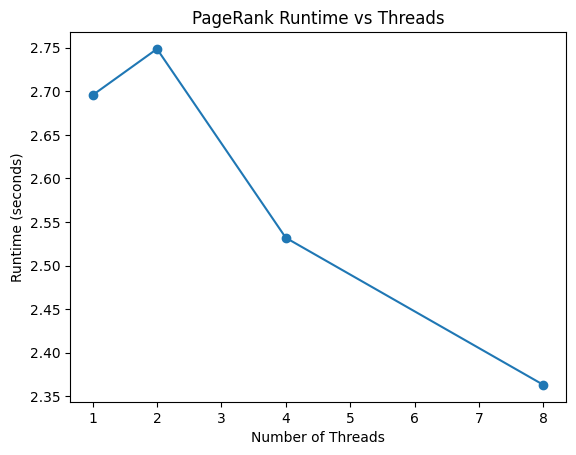

In [24]:
import matplotlib.pyplot as plt

plt.plot(df_threads["Threads"], df_threads["Runtime"], marker='o')
plt.xlabel("Number of Threads")
plt.ylabel("Runtime (seconds)")
plt.title("PageRank Runtime vs Threads")
plt.show()


# Louvain

In [25]:
import networkx as nx
import community as community_louvain
import time



# STEP 1.2 — Run CPU Louvain

In [26]:
start_time = time.time()

partition = community_louvain.best_partition(G)

end_time = time.time()

cpu_louvain_time = end_time - start_time

print("CPU Louvain completed.")
print("Execution time:", cpu_louvain_time, "seconds")

CPU Louvain completed.
Execution time: 44.353917598724365 seconds


# STEP 1.3 — Calculate Modularity

In [27]:

modularity_cpu = community_louvain.modularity(partition, G)

print("Modularity:", modularity_cpu)


Modularity: 0.2917131284238334


# STEP 1.4 — Count Communities

In [28]:
from collections import Counter

community_sizes = Counter(partition.values())

print("Number of communities:", len(community_sizes))

# Show top 5 largest communities
print("Largest communities:", community_sizes.most_common(5))

Number of communities: 9
Largest communities: [(0, 6435), (5, 5974), (2, 4502), (1, 4151), (4, 3383)]


# STEP 1.5 — Map Back to Protein Names

In [29]:

id_to_protein = {v: k for k, v in protein_to_id.items()}

# Get proteins in largest community
largest_comm_id = community_sizes.most_common(1)[0][0]

largest_comm_nodes = [
    id_to_protein[node]
    for node, comm in partition.items()
    if comm == largest_comm_id
]

print("Proteins in largest community (first 10):")
print(largest_comm_nodes[:10])

Proteins in largest community (first 10):
['MAP2K4', 'ACTN2', 'APP', 'APPBP2', 'APLP1', 'DAB1', 'RALGDS', 'CSF1R', 'GRB2', 'CDH15']
